In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn import datasets, manifold
%matplotlib inline


In [7]:
import ssl
import urllib.request

ssl._create_default_https_context = ssl._create_unverified_context
response = urllib.request.urlopen('https://example.com')


In [ ]:
# response

<Response [200]>

In [9]:
# data = datasets.fetch_openml("mnist_784",version=1,return_X_y=True)
housing_data = pd.read_csv("/Users/user/Documents/housing/housing.csv")

In [12]:
housing_data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
# len(housing_data)

20640

In [14]:
housing_data["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [16]:
housing_data.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


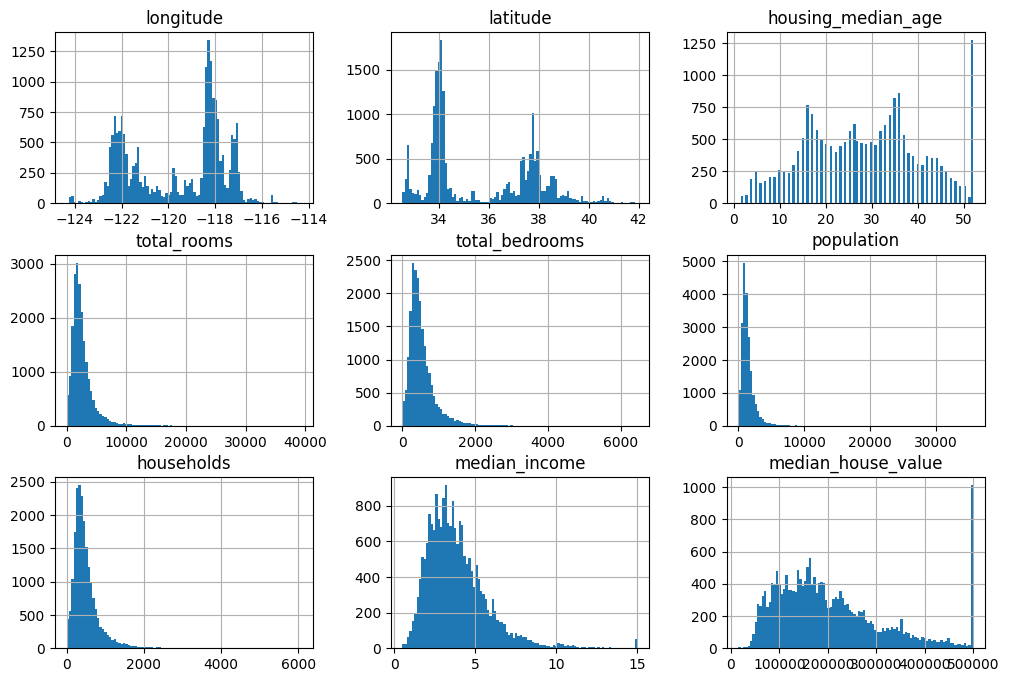

In [22]:
housing_data.hist(bins=100,figsize=(12,8))
plt.show()

In [24]:
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(housing_data,test_size=0.2,random_state=42)

In [28]:
# convert features to categorical features.
housing_data["income_cat"] = (pd.cut(housing_data["median_income"],bins=[0,1.5,3,4.5,6,np.inf],labels=[1,2,3,4,5]))

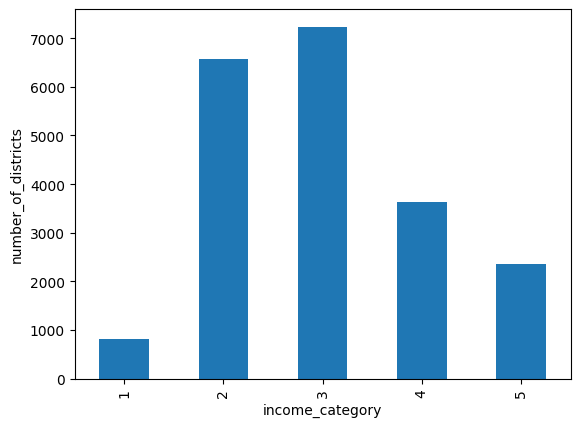

In [31]:
housing_data["income_cat"].value_counts().sort_index().plot.bar()
plt.xlabel("income_category")
plt.ylabel("number_of_districts")
plt.show()

In [34]:
# stratified train test set creation and also creating data for cross_validation.
from sklearn.model_selection import StratifiedShuffleSplit
splitter = StratifiedShuffleSplit(n_splits=10,test_size=0.2,random_state=9)
strat_splits = []
for split_train_idx,split_test_idx in splitter.split(housing_data,housing_data["income_cat"]):
    train_data = housing_data.iloc[split_train_idx]
    test_data = housing_data.iloc[split_test_idx]
    strat_splits.append([train_data,test_data])


In [37]:
#simply
train_data,test_data = train_test_split(housing_data,test_size=0.2,stratify=housing_data["income_cat"],random_state=42)

In [ ]:
test_data["income_cat"].value_counts()/

income_cat
3    1447
2    1316
4     728
5     472
1     165
Name: count, dtype: int64

In [40]:
#droping a column from df
for data_set in (train_data,test_data):
    data_set.drop("income_cat",axis=1,inplace=True)

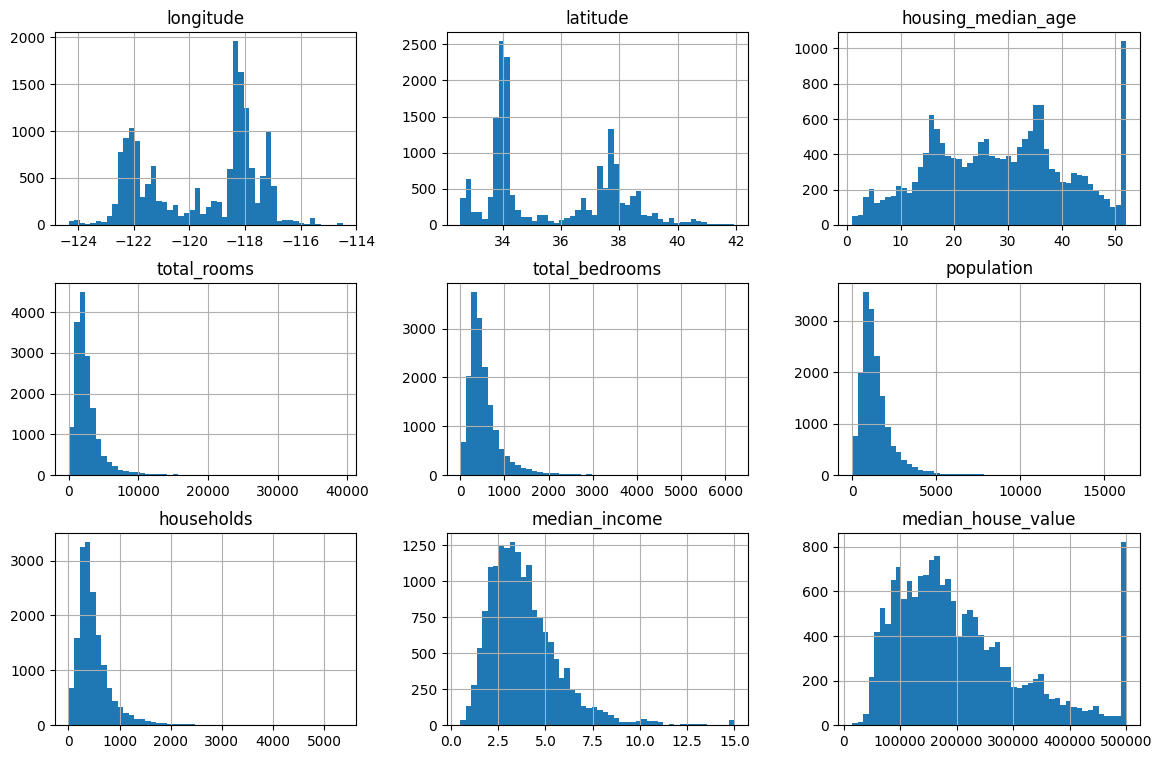

In [ ]:
train_data.hist(bins = 50,figsize=(14,9))
# plt.show()

Data visualization

In [45]:
housing = train_data.copy()

<Axes: xlabel='longitude', ylabel='latitude'>

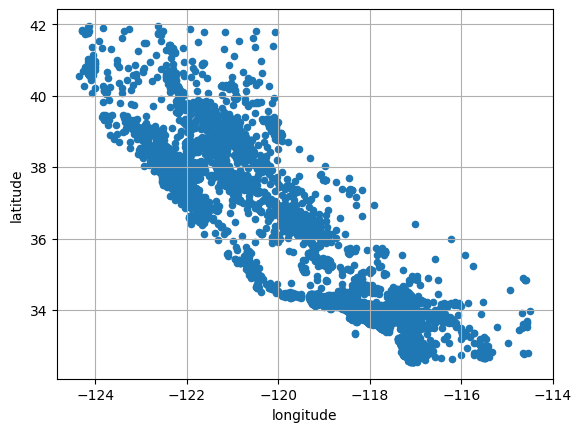

In [47]:
housing.plot(kind="scatter",x="longitude",y="latitude",grid=True)

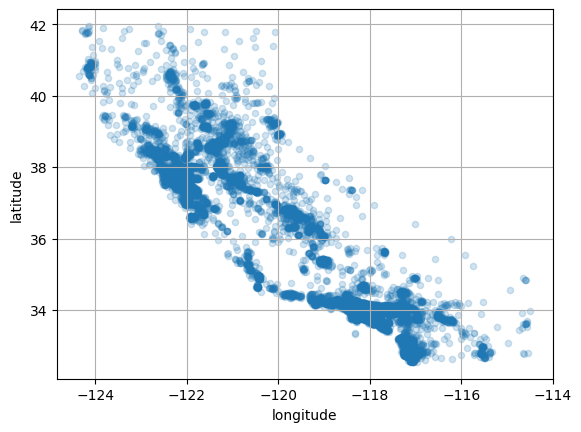

In [52]:
#change alpha to see the high density of the points.
housing.plot(kind="scatter",x="longitude",y="latitude",grid=True,alpha=0.2)
plt.show()

In [55]:
#look for correlations(simple way of feature selection)
corr_matrics = housing.corr(numeric_only=True)

In [56]:
corr_matrics["median_house_value"].sort_values()

latitude             -0.139584
longitude            -0.050859
population           -0.020153
total_bedrooms        0.054635
households            0.071426
housing_median_age    0.102175
total_rooms           0.137455
median_income         0.688380
median_house_value    1.000000
Name: median_house_value, dtype: float64

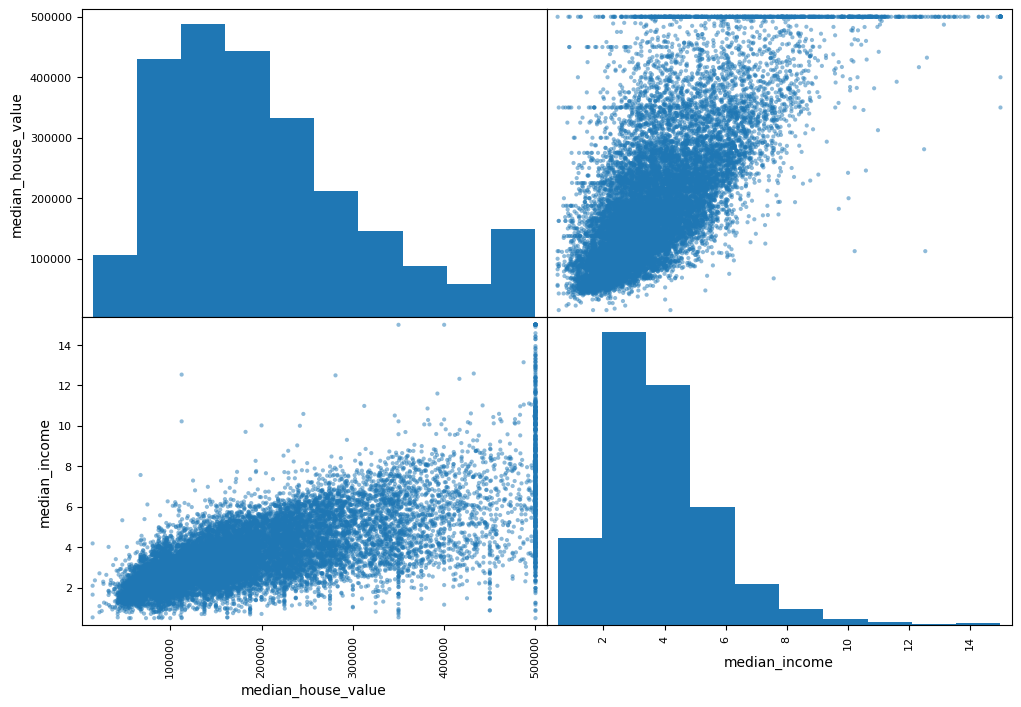

In [59]:
# use pandas scatter_matrix to plot the correlation
from pandas.plotting import scatter_matrix
attributes = ["median_house_value","median_income"]
scatter_matrix(housing[attributes],figsize=(12,8))
plt.show()

In [63]:
housing["rooms_per_house"] = housing["total_rooms"]/housing["households"]
housing["bedrooms_ratio"] = housing["total_bedrooms"]/housing["total_rooms"]
housing["people_per_house"] = housing["population"]/housing["households"]



In [68]:
correletion_matrix = housing.corr(numeric_only=True)
correletion_matrix["median_house_value"].sort_values()

bedrooms_ratio       -0.256397
latitude             -0.139584
longitude            -0.050859
people_per_house     -0.038224
population           -0.020153
total_bedrooms        0.054635
households            0.071426
housing_median_age    0.102175
total_rooms           0.137455
rooms_per_house       0.143663
median_income         0.688380
median_house_value    1.000000
Name: median_house_value, dtype: float64

In [160]:
housing_labels = housing["median_house_value"].copy()
housing = housing.drop("median_house_value",axis=1)
# housing_labels.head()

In [ ]:
# housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,rooms_per_house,bedrooms_ratio,people_per_house
13096,-122.42,37.80,52.0,3321.0,1115.0,1576.0,1034.0,2.0987,3.0,3.211799,0.335742,1.524178
14973,-118.38,34.14,40.0,1965.0,354.0,666.0,357.0,6.0876,0.0,5.504202,0.180153,1.865546
3785,-121.98,38.36,33.0,1083.0,217.0,562.0,203.0,2.4330,1.0,5.334975,0.200369,2.768473
14689,-117.11,33.75,17.0,4174.0,851.0,1845.0,780.0,2.2618,1.0,5.351282,0.203881,2.365385
20507,-118.15,33.77,36.0,4366.0,1211.0,1912.0,1172.0,3.5292,4.0,3.725256,0.277371,1.631399


Data Cleaning

In [ ]:
#missing data handle three options 1. get rid of those samples 2. get rid of those attributes 3. impute the missing values.
# housing.dropna("total_bedrooms")
# housing.drop("total_bedrooms",axis=1)
# housing["total_bedrooms"].fillna(median,inplace=True)


TypeError: DataFrame.dropna() takes 1 positional argument but 2 positional arguments (and 1 keyword-only argument) were given

In [162]:
#scikit learns imputer
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median") #this imputer wont work for categorical features
housing_num = housing.select_dtypes(include=[np.number])

imputer.fit(housing_num)
imputer.statistics_

array([-1.18510000e+02,  3.42600000e+01,  2.90000000e+01,  2.12500000e+03,
        4.34000000e+02,  1.16700000e+03,  4.08000000e+02,  3.53850000e+00,
        1.00000000e+00,  5.23557310e+00,  2.03105786e-01,  2.82231619e+00])

In [163]:
housing_num.median().values

array([-1.18510000e+02,  3.42600000e+01,  2.90000000e+01,  2.12500000e+03,
        4.34000000e+02,  1.16700000e+03,  4.08000000e+02,  3.53850000e+00,
        1.00000000e+00,  5.23557310e+00,  2.03105786e-01,  2.82231619e+00])

In [164]:
X = imputer.transform(housing_num)

In [ ]:
#More powerfull imputers in available in sklearn, KNN imputer, Iterative Imputer

In [ ]:
# X.head()
# housing_num.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_house,bedrooms_ratio,people_per_house
13096,-122.42,37.80,52.0,3321.0,1115.0,1576.0,1034.0,2.0987,458300.0,3.211799,0.335742,1.524178
14973,-118.38,34.14,40.0,1965.0,354.0,666.0,357.0,6.0876,483800.0,5.504202,0.180153,1.865546
3785,-121.98,38.36,33.0,1083.0,217.0,562.0,203.0,2.4330,101700.0,5.334975,0.200369,2.768473
14689,-117.11,33.75,17.0,4174.0,851.0,1845.0,780.0,2.2618,96100.0,5.351282,0.203881,2.365385
20507,-118.15,33.77,36.0,4366.0,1211.0,1912.0,1172.0,3.5292,361800.0,3.725256,0.277371,1.631399


In [ ]:
# housing_tr = pd.DataFrame(X,columns=housing_num.columns,index = housing_num.index)

In [165]:
#handling text and categorical attributes
housing_cat = housing[["ocean_proximity"]]

In [166]:
housing_cat.value_counts()

ocean_proximity
0.0                7274
1.0                5301
4.0                2089
3.0                1846
2.0                   2
Name: count, dtype: int64

In [108]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
# ordinal_encoder = OrdinalEncoder()
onehotencoder = OneHotEncoder()
# housing_cat_encoded = ordinal_encoder.fit_transform(housing_cat)
housing_cat_encoded = onehotencoder.fit_transform(housing_cat)

housing_cat_encoded[:5,:]

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 5 stored elements and shape (5, 5)>

In [119]:
housing_cat_with_numeric = pd.DataFrame(housing_cat_encoded,columns = housing_cat.columns)
housing_cat_with_numeric.head()
# housing["ocean_proximity"] = housing_cat_encoded

,ocean_proximity
0,<Compressed Sparse Row sparse matrix of dtype ...
1,<Compressed Sparse Row sparse matrix of dtype ...
2,<Compressed Sparse Row sparse matrix of dtype ...
3,<Compressed Sparse Row sparse matrix of dtype ...
4,<Compressed Sparse Row sparse matrix of dtype ...


In [105]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,rooms_per_house,bedrooms_ratio,people_per_house
13096,-122.42,37.80,52.0,3321.0,1115.0,1576.0,1034.0,2.0987,458300.0,3.0,3.211799,0.335742,1.524178
14973,-118.38,34.14,40.0,1965.0,354.0,666.0,357.0,6.0876,483800.0,0.0,5.504202,0.180153,1.865546
3785,-121.98,38.36,33.0,1083.0,217.0,562.0,203.0,2.4330,101700.0,1.0,5.334975,0.200369,2.768473
14689,-117.11,33.75,17.0,4174.0,851.0,1845.0,780.0,2.2618,96100.0,1.0,5.351282,0.203881,2.365385
20507,-118.15,33.77,36.0,4366.0,1211.0,1912.0,1172.0,3.5292,361800.0,4.0,3.725256,0.277371,1.631399


Feature Scaling and Transformation

In [111]:
#Two scaling techniques are there 1. min max scaling 2. standardization
from sklearn.preprocessing import MinMaxScaler, StandardScaler
min_max_scaler = MinMaxScaler()
std_scaler = StandardScaler()

housing_num_std_scaled = std_scaler.fit_transform(housing_num)
housing_num_min_max_scaled = min_max_scaler.fit_transform(housing_num)

In [112]:
housing_num_std_scaled[:5]

array([[-1.42303652,  1.0136059 ,  1.86111875,  0.31191221,  1.35909429,
         0.13746004,  1.39481249, -0.93649149,  2.18511202, -0.86602737,
         2.14135179, -0.33020372],
       [ 0.59639445, -0.702103  ,  0.90762971, -0.30861991, -0.43635598,
        -0.69377062, -0.37348471,  1.17194198,  2.40625396,  0.0245495 ,
        -0.56854491, -0.25361631],
       [-1.2030985 ,  1.27611874,  0.35142777, -0.71224036, -0.75958421,
        -0.78876841, -0.77572662, -0.75978881, -0.90740625, -0.04119332,
        -0.21643202, -0.05104091],
       [ 1.23121557, -0.88492444, -0.91989094,  0.70226169,  0.73623112,
         0.38317548,  0.73137454, -0.85028088, -0.95597075, -0.03485833,
        -0.15526672, -0.14147547],
       [ 0.71136206, -0.87554898,  0.58980003,  0.79012465,  1.58558998,
         0.44437597,  1.75526303, -0.18036472,  1.34824154, -0.66655412,
         1.12469526, -0.30614815]])

In [114]:
housing_num_scaled_data = pd.DataFrame(housing_num_std_scaled,columns=housing_num.columns)

In [127]:
housing_num_scaled_data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_house,bedrooms_ratio,people_per_house
0,-1.423037,1.013606,1.861119,0.311912,1.359094,0.137460,1.394812,-0.936491,2.185112,-0.866027,2.141352,-0.330204
1,0.596394,-0.702103,0.907630,-0.308620,-0.436356,-0.693771,-0.373485,1.171942,2.406254,0.024550,-0.568545,-0.253616
2,-1.203098,1.276119,0.351428,-0.712240,-0.759584,-0.788768,-0.775727,-0.759789,-0.907406,-0.041193,-0.216432,-0.051041
3,1.231216,-0.884924,-0.919891,0.702262,0.736231,0.383175,0.731375,-0.850281,-0.955971,-0.034858,-0.155267,-0.141475
4,0.711362,-0.875549,0.589800,0.790125,1.585590,0.444376,1.755263,-0.180365,1.348242,-0.666554,1.124695,-0.306148


In [139]:
X = np.hstack([housing_num_scaled_data.to_numpy(),housing_cat_encoded.toarray()])

In [142]:
target_scaler = StandardScaler()
Y = target_scaler.fit_transform(housing_labels.to_frame())


In [145]:
from sklearn.impute import SimpleImputer
median_imputer = SimpleImputer(strategy="median") 
X = median_imputer.fit_transform(X)

In [146]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()

lin_reg.fit(X,Y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [148]:
# X[:10]

In [153]:
prediction = target_scaler.inverse_transform(lin_reg.predict(X[:10]))
gt = target_scaler.inverse_transform(Y[:10])

In [155]:
from sklearn.metrics import mean_squared_error
mse_error = mean_squared_error(gt,prediction)

In [156]:
mse_error

7.602120701607345e-21

In [157]:
gt[:10]

array([[458300.],
       [483800.],
       [101700.],
       [ 96100.],
       [361800.],
       [ 92600.],
       [349300.],
       [440900.],
       [160100.],
       [183900.]])

In [158]:
prediction[:10]

array([[458300.],
       [483800.],
       [101700.],
       [ 96100.],
       [361800.],
       [ 92600.],
       [349300.],
       [440900.],
       [160100.],
       [183900.]])